<a href="https://colab.research.google.com/github/IgorVeret119/Deepfake_detective/blob/main/baseline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## `Загрузка данных (1 балл)`

In [ ]:
!pip install yadisk

In [ ]:
TOKEN = "y0__wgBEOqqzbcEGIesRyC5wf_SGDDNzNLrB1UKpR0S6zv56ylh9XeIO-G_bAgG"

In [ ]:
import os

import numpy as np
import numpy.testing as npt
import pandas as pd
import torch
from torchvision.io import read_image
from torch.utils.data import Dataset, DataLoader
from torchvision.models import vgg13, VGG13_Weights
import torch
from PIL import Image
from torchvision import transforms
import matplotlib_inline
import matplotlib.pyplot as plt

%matplotlib inline
matplotlib_inline.backend_inline.set_matplotlib_formats('pdf', 'svg')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
# ============================================
# БЛОК 2: Загрузка и РАСПАКОВКА АРХИВА
# ============================================

import yadisk
import zipfile
import io
import os
from tqdm import tqdm
import concurrent.futures
import requests

TOKEN = "y0__wgBEOqqzbcEGIesRyC5wf_SGDDNzNLrB1UKpR0S6zv56ylh9XeIO-G_bAgG"
y = yadisk.YaDisk(token=TOKEN)

# Получаем ссылку на скачивание
print("Получение ссылки на скачивание...")
download_link = y.get_download_link("/Загрузки/train_stage1.zip")
print(f"✅ Ссылка получена")

# Скачиваем архив на диск (НЕ В ПАМЯТЬ!)
print("Скачивание архива на диск...")
response = requests.get(download_link, stream=True)
total_size = int(response.headers.get('content-length', 0))

# Скачиваем в файл на диске
temp_zip = "temp_archive.zip"
with open(temp_zip, "wb") as f:
    with tqdm(total=total_size, unit='B', unit_scale=True, desc="Скачивание") as pbar:
        for chunk in response.iter_content(chunk_size=8192):
            f.write(chunk)
            pbar.update(len(chunk))

print(f"✅ Архив скачан на диск, размер: {os.path.getsize(temp_zip) / (1024**2):.2f} МБ")

# Распаковываем на диск (НЕ В ПАМЯТЬ!)
extract_dir = "extracted_files"
os.makedirs(extract_dir, exist_ok=True)

print("Распаковка на диск...")
with zipfile.ZipFile(temp_zip, 'r') as zip_ref:
    file_list = [f for f in zip_ref.infolist() if not f.is_dir()]
    print(f"Распаковка {len(file_list)} файлов...")

    for file_info in tqdm(file_list, desc="Распаковка"):
        zip_ref.extract(file_info, extract_dir)

print(f"✅ Распаковано {len(file_list)} файлов на диск")

# Удаляем временный архив
os.remove(temp_zip)
print("✅ Временный архив удален")

In [ ]:
def pad_to_1024(image, mask):
    _, h, w = image.shape

    new_img = torch.zeros(3, 1024, 1024)
    new_mask = torch.zeros(1, 1024, 1024)

    new_img[:, :h, :w] = image
    new_mask[:, :h, :w] = mask

    return new_img, new_mask

In [ ]:
class TrainPhotosDataset(Dataset):
    def __init__(self, images_dir, transforms=None):
        """
        Arguments
        ---------
        images_dir : str
            Path to directory with images

        target_dir : str
            Path to directory with masks.
            Each mask corresponds to one image.
            Corresponding mask and image have the same name, but different format.

        transforms : some collection
            Sequence of transformations for images and masks.

        """
        self.transforms=transforms
        df = pd.read_csv(images_dir)
        self.data_list = list(zip(df['orgl_img_path'], df['chng_img_path'], df['gt_path']))
    def __len__(self):
        return len(self.data_list)

    def __getitem__(self, idx):
        """
        Arguments
        ---------
        idx : int
            Index of image and mask

        Returns
        -------
        (image, mask)
        """
        to_tensor = transforms.ToTensor()


        image = to_tensor(Image.open(os.path.join('/content/extracted_files',self.data_list[idx][1])).convert('RGB'))
        mask = (to_tensor(Image.open(os.path.join('/content/extracted_files',self.data_list[idx][2])).convert('L')) > 0.5).float()
        image = transforms.Resize((224, 224))(image)
        mask = transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST)(mask)
        if self.transforms is not None:
          for transformer in self.transforms:
            image, mask = transformer(image,mask)
        return image,mask


#### `Просмотр данных`

In [ ]:
#демонстрация картинки

import os
import matplotlib.pyplot as plt
import cv2

folder_path = "/content/extracted_files/stage1/train/mask"

# Берем первый файл
first_file = os.listdir(folder_path)[0]
file_path = os.path.join(folder_path, first_file)

# Читаем и показываем
img = cv2.imread(file_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
plt.imshow(img)
plt.axis('off')
plt.show()

In [ ]:
#какие разрешения есть
import os
import cv2
from collections import Counter

folder_path = "/content/extracted_files/stage1/train/src"

if not os.path.exists(folder_path):
    print("❌ Папка не найдена!")
    exit()

# Получаем все файлы
files = os.listdir(folder_path)

# Фильтруем только изображения
image_extensions = ['.jpg', '.jpeg', '.png', '.bmp', '.tiff']
images = [f for f in files if any(f.lower().endswith(ext) for ext in image_extensions)]

print(f"Всего изображений: {len(images)}")
print("=" * 60)

# Собираем разрешения
resolutions = []
for img_file in images:
    img_path = os.path.join(folder_path, img_file)
    img = cv2.imread(img_path)
    if img is not None:
        h, w = img.shape[:2]
        resolutions.append(f"{w}x{h}")
    else:
        resolutions.append("НЕ ПРОЧИТАНО")

# Считаем уникальные разрешения
resolution_counts = Counter(resolutions)

print("Уникальные разрешения:")
print("=" * 60)
for res, count in sorted(resolution_counts.items()):
    print(f"{res}: {count} шт.")

In [ ]:
# Из прошлого кода у нас есть:
# resolution_counts = Counter(resolutions)
# где ключи - строки вида "WxH"

max_x = 0
max_y = 0

for res_str in resolution_counts.keys():
    w, h = map(int, res_str.split('x'))
    if w > max_x:
        max_x = w
    if h > max_y:
        max_y = h

print(f"max X: {max_x}, max Y: {max_y}")

In [ ]:
'''import os
import yadisk
from tqdm import tqdm
import concurrent.futures

TOKEN = "y0__wgBEOqqzbcEGIesRyC5wf_SGDDNzNLrB1UKpR0S6zv56ylh9XeIO-G_bAgG"
y = yadisk.YaDisk(token=TOKEN)

extract_dir = "extracted_files"

# Собираем все файлы
all_files = []
for root, dirs, files in os.walk(extract_dir):
    for file in files:
        local_path = os.path.join(root, file)
        rel_path = os.path.relpath(local_path, extract_dir)
        all_files.append((local_path, rel_path))

print(f"Найдено {len(all_files)} файлов")

# ШАГ 1: СОЗДАЁМ ТОЛЬКО КОРНЕВУЮ ПАПКУ
root_remote = "/train_stage1_extracted"
if not y.exists(root_remote):
    y.mkdir(root_remote, recursive=True)
print(f"✅ Корневая папка {root_remote} создана")

# ШАГ 2: ФУНКЦИЯ ЗАГРУЗКИ С ПРИНУДИТЕЛЬНЫМ СОЗДАНИЕМ ПАПОК
def upload_file(file_info):
    local_path, rel_path = file_info
    remote_path = f"{root_remote}/{rel_path.replace(os.sep, '/')}"
    remote_dir = os.path.dirname(remote_path)

    # Принудительно создаём папку с recursive=True
    try:
        if not y.exists(remote_dir):
            y.mkdir(remote_dir, recursive=True)
    except Exception as e:
        # Если папка уже существует - игнорируем
        pass

    y.upload(local_path, remote_path, overwrite=True)
    return rel_path

# Параллельная загрузка
print("Загрузка файлов на Яндекс Диск (10 потоков)...")
with concurrent.futures.ThreadPoolExecutor(max_workers=10) as executor:
    results = list(tqdm(
        executor.map(upload_file, all_files),
        total=len(all_files),
        desc="Загрузка"
    ))

print(f"✅ Загружено {len(results)} файлов")'''

## `Модуль аугментации (2 балла)`

Конструктор стандартного `ImageFolder`, принимает параметр `transform` (и иногда `target_transform`).

Они служат для того, чтобы загружаемые изображения (обычно это `PIL.Image`) или таргеты преобразовывать в тензоры нужного вида.

В `torchvision` входит модуль `transforms` для стандартных примеров таких преобразований. В `transforms` могут содержаться случайные преобразования, это самый простой путь для реализации аугментации данных.

При определении кастомного трансформера помимо конструктора нужно реализовать лишь метод `__call__`:

```python
class HorizontalFlip(object):
    def __init__(self, mode=0):
        self.method = mode

    def __call__(self, img):
        """
        Args:
            img (PIL.Image): Image to be flipped.

        Returns:
            PIL.Image: Randomly flipped image.
        """
        if self.method:
            return img.transpose(Image.FLIP_LEFT_RIGHT)
        return img

```

С полным списком стандартных преобразований можно ознакомиться в [документации](https://pytorch.org/vision/0.12/transforms.html).

В данной части вам предлагается самостоятельно реализовать несколько кастомных трансформеров.
Обратите внимание, что для некоторых трансформеров, необходимо преобразовывать и изображение, и маску, а для каких-то только изображение.

Один из путей реализации:
* реализовать декоратор, делающий любое преобразование случайным
* реализовать декоратор, применяющий преобразование и к изображению, и к маске

Список трансформеров, которые надо реализовать:

1. случайное (с вероятностью $p$) горизонтальное отображение (flip) изображения
2. случайное (с вероятностью $p$) вырезание фрагмента изображения (заданного или случайного размера)
3. случайное (с вероятностью $p$) изменение яркости изображения (на заданную или случайную величину)
4. случайное (с вероятностью $p$) изменение фона изображения (на изображение из заданного списка изображений)

Используйте разумные пределы для аугментаций. Одной из причин плохого обучения модели могут быть слишком сильные аугментации. Визуально убедитесь, что граничные случаи достаточно адекватны задаче.

Обратите внимание, что под вырезанием фрагмента подрузумевается вырезания части изображения из исходного, то есть вырезание какой-то части изображения (создание отверстий в изображении). Если после слоя вырезания размеры изображения поменялись, то вы неправильно реализовали модуль.

In [ ]:
class RandomHorizontal(object):
  def __init__(self,p):
    self.p=p
  def __call__(self,x,mask=None):
    if torch.rand(1).item() < self.p:
      return (torch.flip(x, dims=[-1]), None if mask is None else torch.flip(mask,dims=[-1]))
    return (x,mask)
  def __repr__(self):
    return f"Horizontal(p={self.p})"
class RandomCrop(object):
    def __init__(self, p, size=None, random_size=(0,1,0,1)):
        self.p = p
        self.size = size
        self.random_size=random_size
    def __call__(self, x, mask=None):
        if torch.rand(1).item() < self.p:
            if self.size is not None:
                x_coord,y_coord,weight,height=self.size
            else:
                h, w = x.shape[-2], x.shape[-1]
                a,b,c,d=self.random_size
                weight=torch.randint(int(c*w),int(d*w),(1,))
                height=torch.randint(int(a*h),int(b*h),(1,))
                x_coord=torch.randint(0,w-weight,(1,))
                y_coord=torch.randint(0,h-height,(1,))
            new_mask=torch.zeros(x.shape)
            new_mask[...,y_coord:y_coord+height,x_coord:x_coord+weight]=1
            new_mask_for_mask=torch.zeros(mask.shape)
            new_mask_for_mask[...,max(0,y_coord-height//10):min(mask.shape[-2],y_coord+height+height//10),
                              max(0,x_coord-weight//10):min(mask.shape[-1],x_coord+weight+weight//10)]=1
            #return (x*new_mask,mask)
            return (x*new_mask,None if mask is None else mask*new_mask_for_mask)
        return (x,mask)
        F.interpolate(x_batch, size=target_size, mode='bilinear', align_corners=False)
class RandomBright(object):
  def __init__(self,p,value=None,mean=0,std=0.1):
    self.p=p
    self.value=value
    self.std=std
    self.mean=mean
  def __call__(self,x,mask=None):
    if torch.rand(1).item() < self.p:
      if self.value is not None:
        x=x+self.value
      else:
        x=x+(torch.randn((1,))*self.std+self.mean)*x.mean()
    return (x,mask)
class RandomBackground(object):
    def __init__(self, p, images_list, masks_list):
        self.p = p
        self.images_list = images_list
        self.masks_list = masks_list

    def __call__(self, x, mask):
        if torch.rand(1).item() < self.p:
            n = torch.randint(0, len(self.images_list), (1,)).item()
            image = self.images_list[n]
            bg_mask = self.masks_list[n]
            x_new = x.clone()
            anti_mask = (mask == 0).bool().squeeze(0)
            for c in range(3):
              x_new[c, anti_mask] = image[c, anti_mask].float()
            bg_mask_norm = bg_mask.float()
            combined_mask = torch.max(mask.float(), bg_mask_norm)

            return (x_new, combined_mask)
        return (x, mask)

Добавьте случайные преобразования в ваши датасеты. Также, добавьте преобразование в tensor и нормализацию для изображения:

```python
transforms.ToTensor()
transforms.Normalize(
    mean=[0.485, 0.456, 0.406],
    std=[0.229, 0.224, 0.225]
)
```

In [ ]:
train_dataset = TrainPhotosDataset(
    images_dir='/content/extracted_files/stage1/train.csv',
    transforms=[RandomHorizontal(0.25),RandomCrop(0.25),RandomBright(0.25)]
)
'''
test_dataset = TrainPhotosDataset(
    images_dir=,
    transforms=[RandomHorizontal(0.25),RandomCrop(0.25),RandomBright(0.25)]
)'''

Функция для отображения изображения:

In [ ]:
def show_idx_image(dataset, idx):
    image, mask = dataset[idx]

    image = image.permute(1, 2, 0).numpy()
    image = (image * np.array([0.229, 0.224, 0.225])) + np.array([0.485, 0.456, 0.406])
    image = np.clip(image, 0, 1)

    mask = mask.squeeze(0).numpy()

    fig, axes = plt.subplots(1, 2, figsize=(6, 4))

    axes[0].imshow(image)
    axes[1].imshow(mask)

    axes[0].set_axis_off()
    axes[1].set_axis_off()

    fig.tight_layout()
    plt.show()

Отобразите несколько изображений и масок, на которых будет видна правильная работа вашего модуля аугментации данных. Необходимо проверить каждый модуль аугментации отдельно, в ином случае будут сниматься баллы.

**Важно:** Проверьте корректность работы модулей, действительно ли маска изображения корректна для изображения после аугментации.

In [ ]:
test_dataset_1 = TrainPhotosDataset(
    images_dir='/content/extracted_files/stage1/train.csv',
    transforms=[RandomHorizontal(1)]
)
show_idx_image(test_dataset_1,0)

In [ ]:
test_dataset_1 = TrainPhotosDataset(
    images_dir='/content/extracted_files/stage1/train.csv',
    transforms=[RandomCrop(1)]
)
show_idx_image(test_dataset_1,0)

In [ ]:
test_dataset_1 = TrainPhotosDataset(
    images_dir='/content/extracted_files/stage1/train.csv',
    transforms=[RandomBright(1,-0.5)]
)
show_idx_image(test_dataset_1,0)

## `Загрузчики`

При обучении сети удобнее работать не с датасетами, а с загрузчиками. Загрузчики создаются на основе датасета и позволяют итерироваться по батчам из него.

Обратите внимание на параметры `DataLoader`. При `num_workers`$\;> 1$, батчи готовятся (загружаются картинки, обрабатываются и так далее) сразу в нескольких фоновых процессах. С помощью параметра `shuffle` можно подавать картинки на обучение в случайном порядке.

Обычно, скорость обработки данных на GPU превышает скорость загрузки данных в одном процессе, поэтому типичное значение для `num_workers`$\approx 3\text{-}10$.

Учтите, что на некоторых системах в Jupyter Notebook при `num_workers`$>0$ `DataLoader` перестаёт работать. В таком случае установите это значение в $0$.

In [ ]:
#test_data_loader = DataLoader(test_dataset, batch_size=8, num_workers=3)
train_data_loader = DataLoader(train_dataset, batch_size=8, num_workers=3, shuffle=True)

## `DiceLoss (1 балл)`

Функция потерь реализовывается как и все стандартные нейронные модули в pytorch, через `torch.nn.Module`. В ячейке ниже вам предлагается реализовать функцию потерь `dice` (аналог меры Жаккарда).

Результат **Dice Loss** определим как:

$$
\text{Dice Coefficient} = 2\frac{|A \cap B| }{|A| + |B|} \leadsto \text{Dice Loss} = 1 - \frac{2\sum\limits_{i, j}a_{ij}b_{ij}}{\sum\limits_{ij}(a_{ij} + b_{ij} + \varepsilon)}
$$

где $a_{ij} \in [0, 1]$ — предсказанная вероятность нахождения человека в пикселе изображения, $b_{ij}$ — истинная разметка для пикселя изображения.

In [ ]:
class DiceLoss(torch.nn.Module):
    def __init__(self, eps=1e-7, reduction=None, with_logits=True):
        """
        Arguments
        ---------
        eps : float
            eps in denominator
        reduction : Optional[str] (None, 'mean' or 'sum')
            specifies the reduction to apply to the output:

            None: no reduction will be applied
            'mean': the sum of the output will be divided by the number of elements in the batch
            'sum':  the output will be summed.
        with_logits : bool
            If True, use additional sigmoid for inputs
        """
        super().__init__()
        self.eps = eps
        self.reduction = reduction
        self.with_logits = with_logits

    def forward(self, logits, true_labels):
        """
        Arguments
        ---------
        logits: torch.Tensor
            Unnormalized probability of true class. Shape: [B, ...]
        true_labels: torch.Tensor
            Mask of correct predictions. Shape: [B, ...]
        Returns
        -------
        torch.Tensor
            If reduction is 'mean' or 'sum' returns a tensor with a single element
            Otherwise, returns a tensor of shape [B]
        """
        true_labels = true_labels.to(torch.long)

        if self.with_logits:
            logits=torch.sigmoid(logits)
        axis=(tuple(range(1, logits.ndim)))
        a=(2*logits*true_labels).sum(dim=axis)
        b=logits.sum(dim=axis)+self.eps
        c=true_labels.sum(dim=axis)
        res=torch.ones((logits.shape[0],)).to(device)-a/(b+c)

        if self.reduction == 'sum':
            # your code here
            loss_value = res.sum()
        elif self.reduction == 'mean':
            # your code here
            loss_value = res.mean()
        elif self.reduction is None:
            # your code here
            loss_value = res

        return loss_value

Проверка реализации:

In [ ]:
logits = torch.tensor([
    [[0, 0.5], [0.5, 1]],
    [[0.1, 0.1], [0, 0]],
]).to(device)

target = torch.tensor([
    [[0, 1], [1, 1]],
    [[1, 0], [0, 1]],
]).to(device)

losses = DiceLoss(with_logits=False, reduction=None, eps=1e-7)(logits, target)
npt.assert_almost_equal(losses.cpu().numpy(), np.array([0.2, 0.90909]), decimal=4)

loss = DiceLoss(with_logits=False, reduction='mean', eps=1e-7)(logits, target)
npt.assert_almost_equal(float(loss.cpu().numpy()), 0.554545, decimal=4)

loss = DiceLoss(with_logits=False, reduction='sum', eps=1e-7)(logits, target)
npt.assert_almost_equal(float(loss.cpu().numpy()), 1.10909, decimal=4)

## `U-Net (3 балла)`

Для решения задачи сегментации будем использовать [U-Net](https://arxiv.org/pdf/1505.04597.pdf) с энкодером из первых блоков предобученного `VGG13`.

Концептуальная схема представлена на диаграмме ниже:

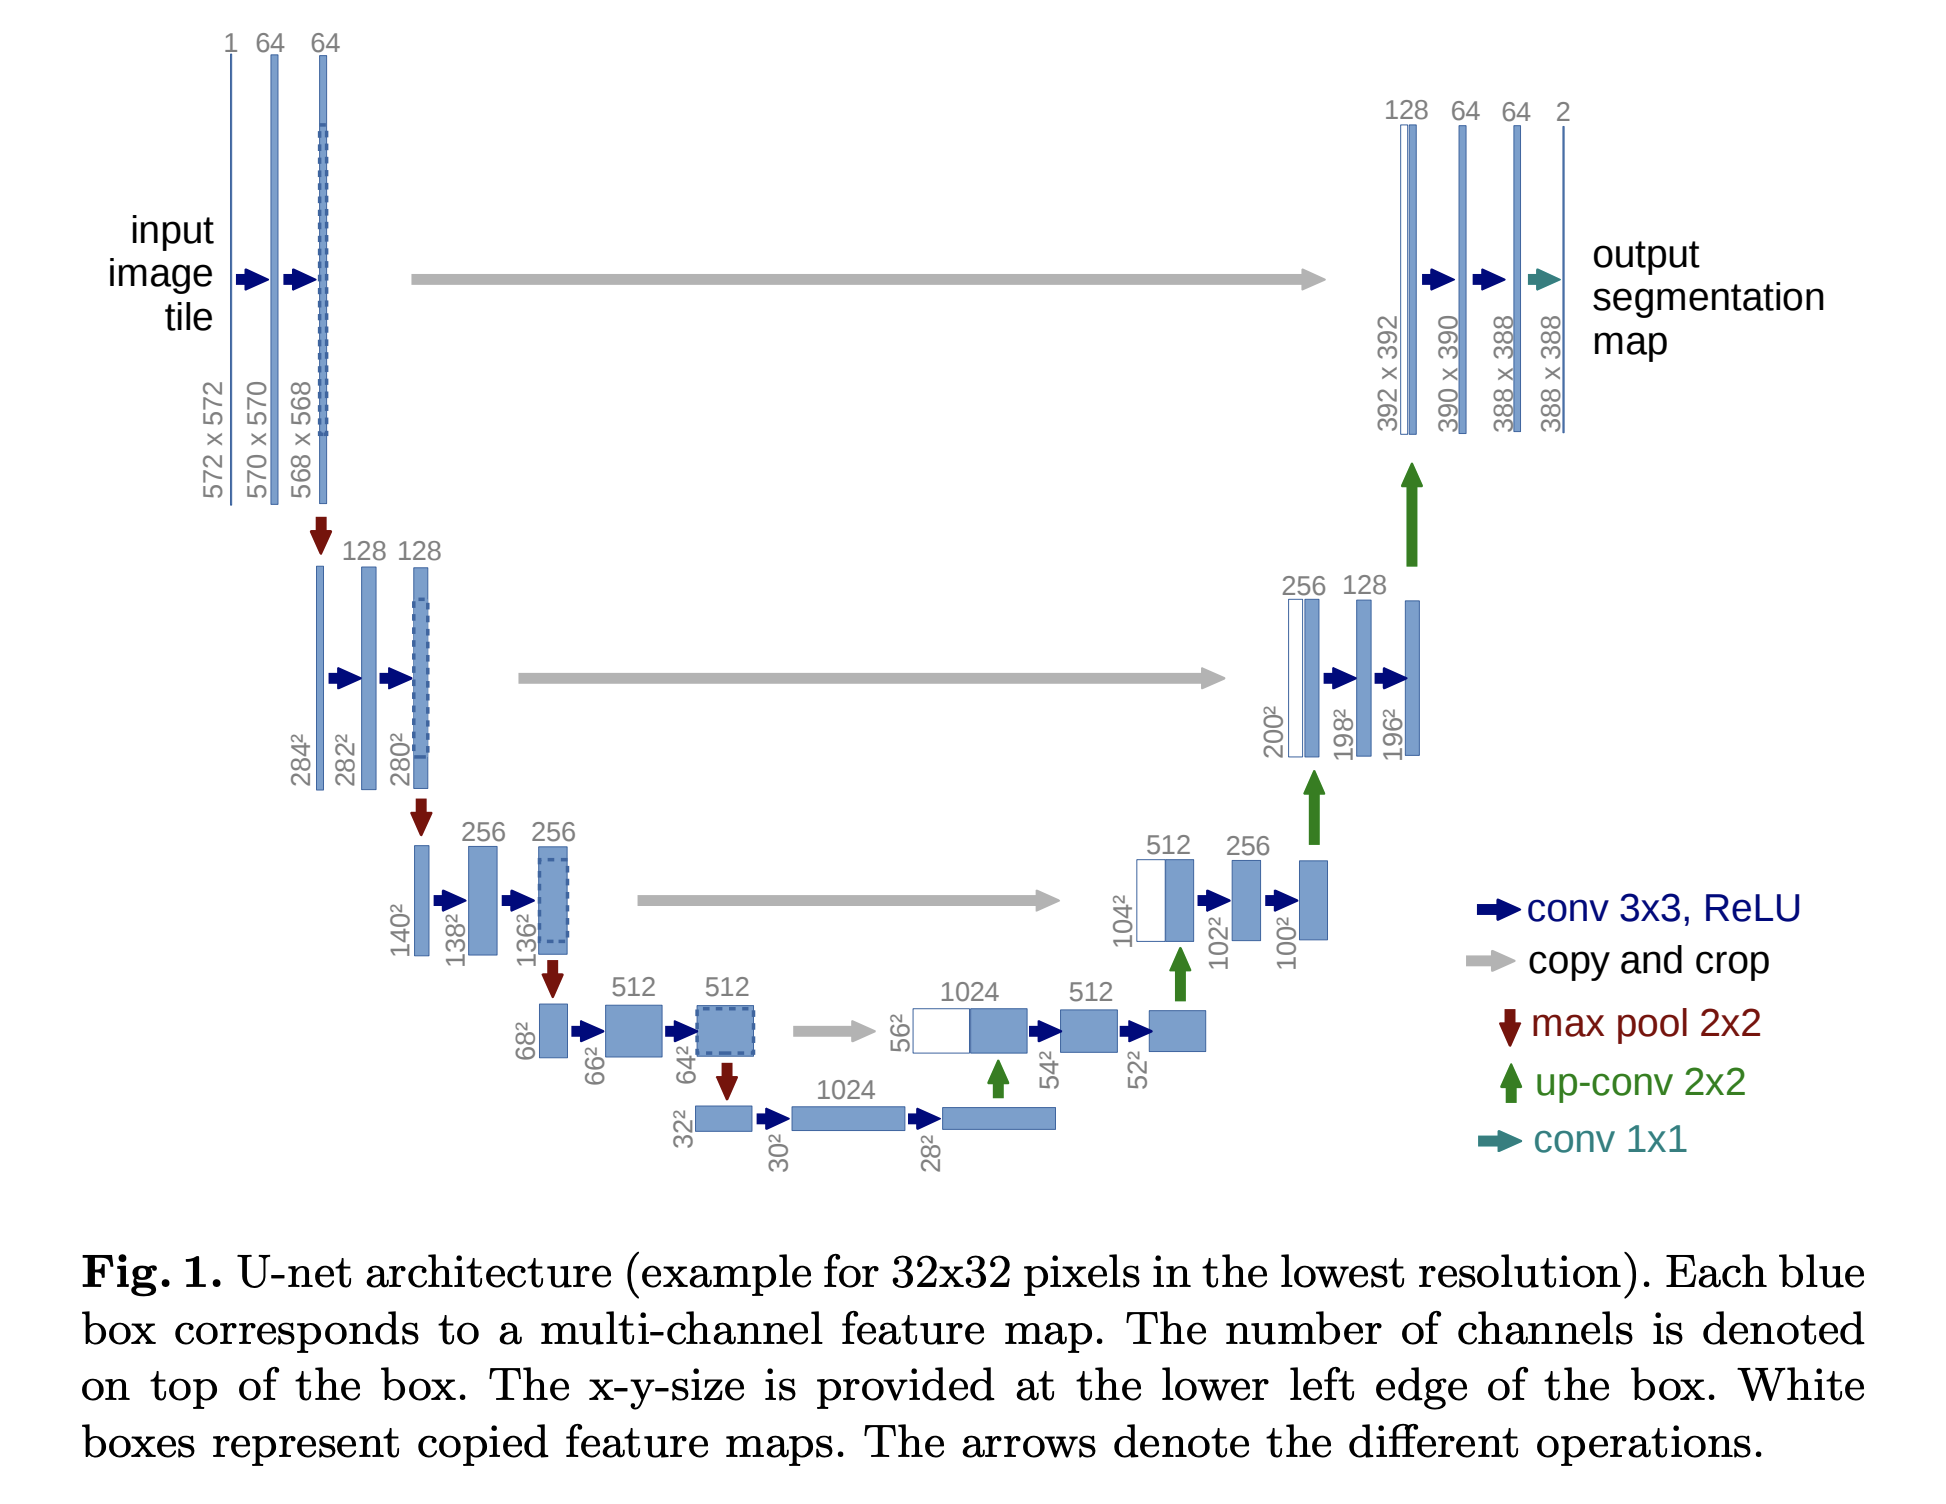

Заметим, что блоки VGG13 имеют следующий вид:
```python
    (0): Conv2d(...)
    (1): ReLU(...)
    (2): Conv2d(...)
    (3): ReLU(...)
    (4): MaxPool2d(...)
```

Для удобства, уберём слои `MaxPool2d` из блоков энкодера и будем применять pooling отдельно. Возможно, вам будет полезно вывести архитектуру модели `VGG` и изучить параметры слоев pooling.

При реализации `Decoder` вам пригодится интерполяция, для этого можно использовать `torch.nn.functional.interpolate` с `mode=nearest`.

Реализуйте архитектуру данной сети.

#### `Encoder`

In [ ]:
from torch import nn
from copy import deepcopy
class VGG13Encoder(torch.nn.Module):
    def __init__(self, num_blocks, weights=VGG13_Weights.DEFAULT):
        super().__init__()
        self.num_blocks = num_blocks

        # Будем использовать предобученную VGG13 в качестве backbone
        feature_extractor = vgg13(weights=weights).features

        # Каждый блок энкодера U-Net — это блок VGG13 без MaxPool2d
        self.blocks = torch.nn.ModuleList()
        tmp=[]
        cur=0
        for idx in range(self.num_blocks):
            # Возьмите нужные слои из `feature_extractor` для очередного U-Net блока
            # Объедините их с помощью `torch.nn.Sequential`
            tmp=[]
            while(not isinstance(feature_extractor[cur],nn.MaxPool2d)):
              tmp.append(deepcopy(feature_extractor[cur]))
              cur+=1
            self.blocks.append(
                  nn.Sequential(*tmp)
            )
            cur+=1
        self.MP=nn.MaxPool2d(kernel_size=2, stride=2, padding=0)


    def forward(self, x):
        activations = []
        for idx, block in enumerate(self.blocks):
            # Примените очередной блок U-Net
            # your code here
            x=block(x)

            # Сохраните активации для передачи их в декодер
            # your code here
            activations.append(x)

            # При необходимости примените max-pool
            # Можно использовать `torch.functional.F.max_pool2d`
            # your code here
            x=self.MP(x) if idx!=len(self.blocks)-1 else x

        return activations

In [ ]:
assert sum((param.numel() for param in VGG13Encoder(num_blocks=1).parameters())) == 38720
assert sum((param.numel() for param in VGG13Encoder(num_blocks=2).parameters())) == 260160
assert sum((param.numel() for param in VGG13Encoder(num_blocks=3).parameters())) == 1145408

x = torch.arange(1 * 3 * 320 * 240).reshape(1, 3, 320, 240) / (1 * 3 * 320 * 240)
out = VGG13Encoder(num_blocks=3)(x)

assert len(out) == 3
npt.assert_almost_equal(torch.linalg.norm(out[0]).item(), 902.218, decimal=3)
npt.assert_almost_equal(torch.linalg.norm(out[1]).item(), 571.030, decimal=3)
npt.assert_almost_equal(torch.linalg.norm(out[2]).item(), 648.068, decimal=3)

#### `Decoder`

In [ ]:
import torch.nn.functional as F
class DecoderBlock(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()

        self.upconv = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv1 = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv2 = torch.nn.Conv2d(
            in_channels=out_channels, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.relu = torch.nn.ReLU()

    def forward(self, down, left):
        # Upsample x2 и свёртка
        # your code here
        x = F.interpolate(down, scale_factor=2, mode='nearest')
        x=self.upconv(x)

        # Конкатенация выхода энкодера и предыдущего блока декодера
        # your code here
        x = torch.cat([x,left],dim=1)

        # Две свёртки с ReLu
        # your code here
        x = self.conv1(x)
        x=self.relu(x)
        x = self.conv2(x)
        x=self.relu(x)

        return x

In [ ]:
class Decoder(torch.nn.Module):
    def __init__(self, num_filters, num_blocks):
        super().__init__()

        self.blocks = torch.nn.ModuleList()
        for idx in range(num_blocks):
            self.blocks.insert(0, DecoderBlock(num_filters * 2 ** idx))

    def forward(self, acts):
        up = acts[-1]
        for block, left in zip(self.blocks, acts[-2::-1]):
            up = block(up, left)
        return up

#### `U-Net`

In [ ]:
class UNet(torch.nn.Module):
    def __init__(self, num_classes=1, num_blocks=4):
        super().__init__()
        # your code here
        self.encoder = VGG13Encoder(num_blocks)

        # your code here
        self.decoder = Decoder(64,num_blocks-1)

        # Свёртка 1x1 для попиксельной агрегации каналов
        # your code here
        self.final = torch.nn.Conv2d(
            in_channels=64, out_channels=num_classes,
            kernel_size=1,
        )

    def forward(self, x):
        x=self.encoder(x)
        x=self.decoder(x)
        x=self.final(x)

        return x

In [ ]:
model = UNet(num_classes=1, num_blocks=3)
x = torch.arange(1 * 3 * 320 * 240).reshape(1, 3, 320, 240) / (1 * 3 * 320 * 240)
assert sum((param.numel() for param in model.parameters())) == 2067649
assert list(model(x).shape) == [1, 1, 320, 240]
model

### `Оценивание качества сети`


Обычно, оптимизируемый функционал сложно интерпретировать, а так же в разных экспериментах могут использоваться разные функции потерь. Поэтому необходимо замерять и отслеживать независимую метрику качества. Предлагается использовать **IoU (Intersection over Union)** — один из стандартных вариантов для задачи сегментации:
$$
\text{IoU} = \frac{|A \cap B|}{|A \cup B|} = \frac{\sum\limits_{ij}a_{ij}b_{ij}}{\sum\limits_{ij}a_{ij} + b_{ij} - a_{ij}b_{ij}}
$$

Учтите, что знаменатель может быть равен нулю, например, если маска нулевая. Такие объекты можно не учитывать при агрегации и пропускать, так как в ином случае подсчет метрики на всем батче будет NaN. В pytorch есть встроенные для этого функции с префиксом nan.


In [ ]:
class IoUScore(torch.nn.Module):
    def __init__(self, threshold, reduction=None,with_logits=True):
        """
        Arguments
        ---------
        threshold : float
            threshold for logits binarization
        reduction : Optional[str] (None, 'mean' or 'sum')
            specifies the reduction to apply to the output:

            None: no reduction will be applied
            'mean': the sum of the output will be divided by the number of elements in the batch
            'sum':  the output will be summed.
        with_logits : bool
            If True, use additional sigmoid for inputs
        """
        super().__init__()

        self.threshold = threshold
        self.reduction = reduction
        self.with_logits=with_logits
    @torch.no_grad()
    def forward(self, logits, true_labels):
        """
        Arguments
        ---------
        logits: torch.Tensor
            Unnormalized probability of true class. Shape: [B, ...]
        true_labels: torch.Tensor
            Mask of correct predictions. Shape: [B, ...]
        Returns
        -------
        torch.Tensor
            If reduction is 'mean' or 'sum' returns a tensor with a single element
            Otherwise, returns a tensor of shape [B]
        """
        if(self.with_logits):
          logits=torch.sigmoid(logits)
        logits=(logits>self.threshold).float()
        axis=[i for i in range(1,logits.ndim)]
        a=(logits*true_labels).sum(dim=axis)
        b=logits.sum(dim=axis)
        c=true_labels.sum(dim=axis)
        score=a/(b+c-a)

        if self.reduction == 'sum':
            # your code here
            score = torch.nansum(score)
        elif self.reduction == 'mean':
            # your code here
            score = torch.nanmean(score)

        return score

In [ ]:
logits = torch.tensor([
    [
        [0.3089,  0.4311, -0.9711],
        [0.9030,  1.0325, -0.7607],
        [0.9648, -0.5528, -1.1010]
    ], [
        [0.8906,  0.8099,  0.4458],
        [2.6215, -1.3198,  0.3142],
        [0.2262, -0.9175, -0.0174]
    ], [
        [0.8906,  0.8099,  0.4458],
        [2.6215, -1.3198,  0.3142],
        [0.2262, -0.9175, -0.0174]
    ]
])
true_labels = torch.tensor([
    [
        [0., 1., 0.],
        [1., 0., 0.],
        [0., 0., 1.]
    ], [
        [1., 1., 1.],
        [1., 0., 1.],
        [1., 0., 0.]
    ], [
        [1., 1., 1.],
        [0., 1., 1.],
        [1., 1., 1.]
    ]
])

scores = IoUScore(0.0,with_logits=False)(logits, true_labels)
npt.assert_almost_equal(scores.numpy(), np.array([0.3333, 1.0000, 0.5556]), decimal=4)

score = IoUScore(0.0, reduction='sum',with_logits=False)(logits, true_labels)
npt.assert_almost_equal(score.item(), 1.8889, decimal=4)

score = IoUScore(0.0, reduction='mean',with_logits=False)(logits, true_labels)
npt.assert_almost_equal(score.item(), 0.6296, decimal=4)

### `Логирование`

При реализации цикла обучения необходимо сохранять метрики $1\text{-}9$ с использованием модуля [torch.utils.tensorboard](https://pytorch.org/docs/stable/tensorboard.html) или с помощью модуля [wandb](https://docs.wandb.ai/tutorials/) вам предлагается самим выбрать более удобный для вас модуль.

Для отслеживания процесса обучения обычно требуется сохранять информацию разных его аспектах.

Для полного контроля над процессом обучения обычно требуется сохранять информацию о разных статистиках. Самыми очевидными являются:
1. Значение функции потерь (лосса) на обучающей и тестовой выборках
2. Метики качества, например, **Dice Coefficient** и **IoU (Intersection over Union)** на обучающей и тестовой выборках

Однако, суррогатные метрики могут не отражать реального качества. Поэтому для моделей, которые выдают визуализируемый результат, обычно логируют предсказания для некоторых объектов выборки. В задаче сегментации естественным вариантом является логирование четвёрки: исходное изображение, истинная маска, маска вероятностей истинного класса, бинаризованная маска.

*Замечание:* лосс и качество на обучающей выборке обычно логируют не только в конце каждой эпохи, но и по отдельным батчам на каждой итерации.

3. Чтобы отслеживать динамику обучения необходимо зафиксировать небольшой набор объектов обучающей и тестовой выборок и после каждой эпохи обучения логировать указанные четыре картинки для каждого объекта.

*Замечание:* можно логировать четвёрки изображений независимо, однако, удобнее объединить их на одной фигуре [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_figure), [реализация через Wandb](https://docs.wandb.ai/guides/track/log/plots/#matplotlib-and-plotly-plots) (лучше делать через fig и Image). Дополнительный плюс — возможность подписать значения метрик для этого объекта в заголовке изображения или добавить colorbar для более простой интерпретации предсказанной маски.

Для удобной категоризации экспериментов обычно в начале обучения сохраняют:

4. Гиперпараметры модели [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_hparams), [реализация через Wandb](https://docs.wandb.ai/guides/track/config/)
5. Структуру модели [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_graph), **про реализацию wandb ниже**

Для исследования технических особенностей обучения полезно логировать следующие статистики:

6. Распределение весов, активаций, градиентов [реализация через Tensorboard](https://pytorch.org/docs/stable/tensorboard.html#torch.utils.tensorboard.writer.SummaryWriter.add_histogram), [реализация через Wandb](https://docs.wandb.ai/ref/python/data-types/histogram/). Сохранять гистограммы каждого параметра после каждой итерации может быть вычислительно неэффективно, поэтому обычно сохраняют распределения весов для каждого отдельного слоя нейронной сети после каждой эпохи.
7. Норма весов и норма градиента на каждой итерации

Наконец, после каждой эпохи можно визуализировать промежуточные представления входных данных:

8. Активации после каждого слоя/блока, как изображения
9. Градиенты функции потерь по активациям для некоторых объектов обучающей выборки, как изображения

*Замечание:* для реализации пунктов 8, 9 менять код модели не требуется. Используйте хуки: [register_full_backward_hook](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_full_backward_hook) (данный хук не работает с inplace операциями, например, с `torch.nn.ReLU(inplace=True)`. Или не используйте inplace операции, или используйте [`Tensor.register_hook`](https://github.com/pytorch/pytorch/issues/61519)), [register_forward_hook](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.register_forward_hook).

Файлы с логами, а также чекпоинты весов модели после итерации с наилучшим валидационным качеством (смотрите [torch.save](https://pytorch.org/docs/stable/generated/torch.save.html) и [torch.nn.Module.state_dict](https://pytorch.org/tutorials/recipes/recipes/what_is_state_dict.html)) для **ВСЕХ** проведённых экспериментов (за исключением упавших, недосчитанных и так далее) необходимо сдать в anytask.

#### `Некоторые советы по wandb`

- При логировании всегда указывайте параметр step, который должен не уменьшаться.

- При логировании изображений лучше их нормировать в диапазон [0, 1] как в функции `show_idx_image` выше. Для логирования предсказаний маски, лучше использовать вероятности. При неправильном диапозоне изображения могут отображаться неверно!

- Вместо логирования изображений, лучше логировать `matplotlib` графики и соответсвующие им `figure`. Кроме того, лучше закрывать все открытые графики, чтобы не перегружать ноутбук. Пример кода:


```python
fig, ax = plt.subplots(...)
...
wandb.log({key: wandb.Image(fig)}, step=global_step)
plt.close('all')
```

- Функционал построение bins в `wandb.Histogram` ограничен, можете посмотреть в сторону аргумента `np_histogram`.

- Wandb не имеет широкого функционала для логирования структуры модели. Есть способ через wandb.watch(net, log_graph=True), но получаемый результаты сильно отличаются от возможностей `tensorboard`. К счастью, `wandb` умеет синхронизировать логи с `Tensorboard` поэтому можно использовать следующую логику:


```python
wandb.init(
    project=project_name,
    name=run_name,
    config=config,
    sync_tensorboard=True        # Синхронизация с tensorboard
)

writer = SummaryWriter(run_name) # Создание логера tensorboard

# Логирование графа модели
writer.add_graph(net, input_x)
writer.close()

train_loop(...)
wandb.finish()
```

- `wandb` по умолчанию сохраняет все логи локально и на сайте в вашем личном хранилище. В случае перезагрузки `Google Colab` локальные файлы не сохраняются! Кроме того, скачивание файлов не через GoogleDisk достаточно продолжительное (в районе 20-30 минут).

- В `wandb` можно легко сохранять код и указать директорию, так вы никогда не забудете какой именно код получает результаты логов.

```python
wandb.init(..., settings=wandb.Settings(code_dir="."))
```

Кроме того, можно сохранить отдельные файлы:

```python
wandb.init(..., save_code=True)
wandb.run.log_code(
    "./",
    include_fn=lambda path: condition(path)
)
```

- В `wandb` есть функция для автоматического логирования весов и градиентов модели `wandb.watch()`, но функционал слишком ограничен и накладывает слишком много накладных расходов. **Лучше писать руками!**

#### `Некоторые советы по tensorboard`

- Функционал и возможности `tensorboard` шире (работа с 3D, продвинутые визуализации).

- `tensorboard` сохраняет логи только локально, то есть после закрытия `Google Colab` ничего не сохранится. В реальных проектах это является сильной стороной, так как гарантирует безопасность и конфиденциальность.

- Для визуализации логов достаточно запустить в ноутбуке или в терминале соответсвующее расширение, однако в случае `Google Colab` для этого приходится прокидывать порты, [подробнее тут](https://stackoverflow.com/questions/47818822/can-i-use-tensorboard-with-google-colab).

- `tensorboard` меньше лагает и более легковесный.


### `Некоторые советы по логированию`

- Вы можете выбрать либо `wandb`, либо `tensorboard`.

- В реальных проектах лучше добавить логирование кода с целью сохранения и воспроизводимости результатов.

- Называйте запуски осмысленно, чтобы по названию можно было понять смысл запуска и варьеруемые параметры.


### `Эксперименты`

In [ ]:
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
def train_model(train_loader,test_loader,loss_func=DiceLoss(reduction='mean'),lr=0.01,optim=torch.optim.Adam,
                eval_func=IoUScore(0.8,reduction='mean'),epochs=4,num_blocks=4,dir_to_log=None):
  model = UNet(num_classes=1, num_blocks=num_blocks).to(device)
  if not(dir_to_log is None):
    writer = SummaryWriter(dir_to_log)
    writer.global_step=0
    etalone=[test_loader.dataset[i] for i in [0,5,7,9]]
    n=0
    for X,y in etalone:
      n+=1
      pred=model(X.unsqueeze(0).to(device))
      pred=(torch.sigmoid(pred)>0.8).float()
      writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
      writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
      writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')
  optimizer=optim(model.parameters(),lr=lr)
  for epoch in tqdm(range(epochs),position=0):
    model.train()
    for X,y in tqdm(train_loader,position=1, leave=False):
      X=X.to(device)
      y=y.to(device)
      pred=model(X)
      loss=loss_func(pred,y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if not(dir_to_log is None):
        with torch.no_grad():
          writer.add_scalar('Loss/train_step', loss.item(), writer.global_step)
          writer.add_scalar('Eval/train_step', eval_func(pred,y).item(), writer.global_step)
          total_weight_norm = sum(p.norm().item() ** 2 for name, p in model.named_parameters() if 'weight' in name) ** 0.5
          total_grad_norm = sum(p.grad.norm().item() ** 2 for name,
                                p in model.named_parameters() if p.grad is not None and 'weight' in name) ** 0.5
          writer.add_scalar('Norm/weights', total_weight_norm, writer.global_step)
          writer.add_scalar('Norm/grad', total_grad_norm, writer.global_step)
          writer.global_step+=1
    if not(dir_to_log is None):
      for name, param in model.named_parameters():
        if 'weight' in name:
          writer.add_histogram(f'weights/{name}', param, epoch)
      for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
          writer.add_histogram(f'gradients/{name}', param.grad, epoch)
      with torch.no_grad():
        model.eval()
        numb=0
        loss=0
        eval=0
        for X,y in test_loader:
          X=X.to(device)
          y=y.to(device)
          numb+=1
          pred=model(X)
          loss+=loss_func(pred,y).item()
          eval+=eval_func(pred,y).item()

        writer.add_scalar('Loss/test_step', loss/numb, writer.global_step)
        writer.add_scalar('Eval/test_step', eval/numb, writer.global_step)
        last_val_loss = loss/numb
        last_val_iou = eval/numb
        n=0
        for X,y in etalone:
          n+=1
          pred=model(X.unsqueeze(0).to(device))
          pred=(torch.sigmoid(pred)>0.8).float()
          writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
          writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
          writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')
  if(dir_to_log is not None):
    writer.add_hparams(
      {'lr':lr,'loss_func':type(loss_func).__name__,'eval_func':type(eval_func).__name__,'threshold':0.8,'n_epochs':epochs,
       'optimizer':optim.__name__,'number+of blocks':num_blocks},
      {'final_loss':last_val_loss,'final_quality':last_val_iou}
        )
  writer.close()

Теперь применим сеть на практике!

Обучите сеть на обучающей выборке и протестируйте качество на тестовой выборке.

Сначала при обучении используйте только кросс-энтропию (`torch.nn.BCEWithLogitsLoss` будет более удобна для бинарного случая). Зафиксируйте результат.

Сравните между собой несколько стратегий оптимизации:
1. Только кросс-энтропия
2. Только dice loss
3. Сумма двух лоссов с весами (попробуйте $3\text{-} 4$ разных соотношения)

**Для всех экспериментов отобразите графики функции потерь и качества за время обучения. Выведите получившиеся маски для нескольких изображений из датасета. Сделайте выводы.**

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
t_start=time.time()
model=train_model(train_data_loader,test_data_loader,epochs=10,lr=0.00001,dir_to_log='/content/IoUScore')
t_unet=time.time()-t_start
!zip -r /content/IoUScore.zip /content/IoUScore

In [ ]:
!zip -r /content/U_net.zip /content/IoUScore

In [ ]:
import warnings
import time
warnings.filterwarnings("ignore", category=UserWarning)
t_start=time.time()
model=train_model(train_data_loader,test_data_loader,loss_func=torch.nn.BCEWithLogitsLoss(),epochs=10,lr=0.00001,dir_to_log='/content/BCE')
t_unet=time.time()-t_start
!zip -r /content/BCE.zip /content/BCE

In [ ]:
class CombinedLoss(torch.nn.Module):
    def __init__(self, loss1, loss2, weight1=1.0, weight2=1.0):
        super().__init__()
        self.loss1 = loss1
        self.loss2 = loss2
        self.weight1 = weight1
        self.weight2 = weight2

    def forward(self, pred, target):
        return self.weight1 * self.loss1(pred, target) + self.weight2 * self.loss2(pred, target)


In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
model_Unet=train_model(train_data_loader,test_data_loader,loss_func=CombinedLoss(torch.nn.BCEWithLogitsLoss(),IoUScore(0.5,reduction='mean')),epochs=10,lr=0.00001,dir_to_log='/content/Combine1_1')
!zip -r /content/Combine1_1.zip /content/Combine1_1

In [ ]:
model=train_model(train_data_loader,test_data_loader,loss_func=CombinedLoss(torch.nn.BCEWithLogitsLoss(),IoUScore(0.5,reduction='mean'),weight1=2.0),epochs=10,lr=0.00001,dir_to_log='/content/Combine2_1')
!zip -r /content/Combine2_1.zip /content/Combine2_1

In [ ]:
model=train_model(train_data_loader,test_data_loader,loss_func=CombinedLoss(torch.nn.BCEWithLogitsLoss(),IoUScore(0.5,reduction='mean'),weight2=2.0),epochs=10,lr=0.00001,dir_to_log='/content/Combine1_2')
!zip -r /content/Combine1_2.zip /content/Combine1_2

## `LinkNet (2 балла)`

Реализуйте архитектуру [LinkNet](https://arxiv.org/pdf/1707.03718.pdf) с использованием энкодера, основанного на `VGG13`. Архитектура похожа на `Unet`, но вместо конкатенации слоёв используются skip-connections (сложения). Для реализации достаточно переписать структуру декодировщика из предыдущего пункта.

*Подсказка:* так как конкатенации слоёв заменили на skip-connections, то ожидается, что число параметров стало меньше.

**Обучите сеть и проведите анализ согласно предыдущему пункту. Сравните LinkNet и U-Net по качеству и скорости работы. Сделайте выводы.**

In [ ]:
import torch.nn.functional as F
class DecoderBlock_link(torch.nn.Module):
    def __init__(self, out_channels):
        super().__init__()

        self.upconv = torch.nn.Conv2d(
            in_channels=out_channels * 2, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv1 = torch.nn.Conv2d(
            in_channels=out_channels , out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.conv2 = torch.nn.Conv2d(
            in_channels=out_channels, out_channels=out_channels,
            kernel_size=3, padding=1, dilation=1
        )
        self.relu = torch.nn.ReLU()

    def forward(self, down, left):
        # Upsample x2 и свёртка
        # your code here
        x = F.interpolate(down, scale_factor=2, mode='nearest')
        x=self.upconv(x)

        # Конкатенация выхода энкодера и предыдущего блока декодера
        # your code here
        x +=left# torch.cat([x,left],dim=1)

        # Две свёртки с ReLu
        # your code here
        x = self.conv1(x)
        x=self.relu(x)
        x = self.conv2(x)
        x=self.relu(x)

        return x

In [ ]:
class Decoder_link(torch.nn.Module):
    def __init__(self, num_filters, num_blocks):
        super().__init__()

        self.blocks = torch.nn.ModuleList()
        for idx in range(num_blocks):
            self.blocks.insert(0, DecoderBlock_link(num_filters * 2 ** idx))

    def forward(self, acts):
        up = acts[-1]
        for block, left in zip(self.blocks, acts[-2::-1]):
            up = block(up, left)
        return up

In [ ]:
class Link_net(torch.nn.Module):
    def __init__(self, num_classes=1, num_blocks=4):
        super().__init__()
        # your code here
        self.encoder = VGG13Encoder(num_blocks)

        # your code here
        self.decoder = Decoder_link(64,num_blocks-1)

        # Свёртка 1x1 для попиксельной агрегации каналов
        # your code here
        self.final = torch.nn.Conv2d(
            in_channels=64, out_channels=num_classes,
            kernel_size=1,
        )

    def forward(self, x):
        x=self.encoder(x)
        x=self.decoder(x)
        x=self.final(x)

        return x

In [ ]:
from tqdm.notebook import tqdm
from torch.utils.tensorboard import SummaryWriter
def train_link_model(train_loader,test_loader,loss_func=DiceLoss(reduction='mean'),lr=0.01,optim=torch.optim.Adam,
                eval_func=IoUScore(0.8,reduction='mean'),epochs=4,num_blocks=4,dir_to_log=None):
  model = Link_net(num_classes=1, num_blocks=num_blocks).to(device)
  if not(dir_to_log is None):
    writer = SummaryWriter(dir_to_log)
    writer.global_step=0
    etalone=[test_loader.dataset[i] for i in [0,5,7,9]]
    n=0
    for X,y in etalone:
      n+=1
      pred=model(X.unsqueeze(0).to(device))
      pred=(torch.sigmoid(pred)>0.8).float()
      writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
      writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
      writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')
  optimizer=optim(model.parameters(),lr=lr)
  for epoch in tqdm(range(epochs),position=0):
    model.train()
    for X,y in tqdm(train_loader,position=1, leave=False):
      X=X.to(device)
      y=y.to(device)
      pred=model(X)
      loss=loss_func(pred,y)
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()
      if not(dir_to_log is None):
        with torch.no_grad():
          writer.add_scalar('Loss/train_step', loss.item(), writer.global_step)
          writer.add_scalar('Eval/train_step', eval_func(pred,y).item(), writer.global_step)
          total_weight_norm = sum(p.norm().item() ** 2 for name, p in model.named_parameters() if 'weight' in name) ** 0.5
          total_grad_norm = sum(p.grad.norm().item() ** 2 for name,
                                p in model.named_parameters() if p.grad is not None and 'weight' in name) ** 0.5
          writer.add_scalar('Norm/weights', total_weight_norm, writer.global_step)
          writer.add_scalar('Norm/grad', total_grad_norm, writer.global_step)
          writer.global_step+=1
    if not(dir_to_log is None):
      for name, param in model.named_parameters():
        if 'weight' in name:
          writer.add_histogram(f'weights/{name}', param, epoch)
      for name, param in model.named_parameters():
        if param.grad is not None and 'weight' in name:
          writer.add_histogram(f'gradients/{name}', param.grad, epoch)
      with torch.no_grad():
        model.eval()
        numb=0
        loss=0
        eval=0
        for X,y in test_loader:
          X=X.to(device)
          y=y.to(device)
          numb+=1
          pred=model(X)
          loss+=loss_func(pred,y).item()
          eval+=eval_func(pred,y).item()

        writer.add_scalar('Loss/test_step', loss/numb, writer.global_step)
        writer.add_scalar('Eval/test_step', eval/numb, writer.global_step)
        last_val_loss = loss/numb
        last_val_iou = eval/numb
        n=0
        for X,y in etalone:
          n+=1
          pred=model(X.unsqueeze(0).to(device))
          pred=(torch.sigmoid(pred)>0.8).float()
          writer.add_image(f'Images/example_{n}/Image', X.squeeze(0), writer.global_step, dataformats='CHW')
          writer.add_image(f'Images/example_{n}/Mask', y, writer.global_step, dataformats='CHW')
          writer.add_image(f'Images/example_{n}/Result', pred.cpu().squeeze(0), writer.global_step, dataformats='CHW')
  if(dir_to_log is not None):
    writer.add_hparams(
      {'lr':lr,'loss_func':type(loss_func).__name__,'eval_func':type(eval_func).__name__,'threshold':0.8,'n_epochs':epochs,
       'optimizer':optim.__name__,'number+of blocks':num_blocks},
      {'final_loss':last_val_loss,'final_quality':last_val_iou}
        )
  writer.close()

In [ ]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
t_start=time.time()
model_linknet=train_link_model(train_data_loader,test_data_loader,epochs=10,lr=0.00001,dir_to_log='/content/Link_net')
t_linknet=time.time()-t_start

In [ ]:
!zip -r /content/Link_net.zip /content/Link_net

In [ ]:
t_unet, t_linknet

Как видно, время обучения у Link-net значительно ниже, чем у U_net, если просмотреть файлы логов, видно, что качество растет практически синхронно, при этом, финальное качество Link-net слегка превосходит U-net, что говорит об эффективности данной архитектуры.

## `Теоретические вопросы (1 балл)`

### `Вопрос 1`
* Сформулируйте два предположения о структуре входных данных, на которые опирается архитектура свёрточных сетей.
* Какие преимущества дает использование сверток в случае, если эти предположения верные?
* Приведите пример входных данных, когда эти предположения не выполняются.

Предположения:
1)Должна быть высокая пространственная автокорреляция данных, то есть, значение в конкретной точке можно с высокой точностью определить, зная локальный контекст
2)Информация равномерно распределена по данным и концентрироваться в случайных областях
Преимущества:
1)Иерархическое извлечение признаков, после каждой свертки информация получает более высокоуровневое представление.
2)Сеть лучше учитывает 3-мерную структуру данных, что увеличивает информативность данных.
3)уменьшение числа параметров, за счет того, что в каждый нейрон поступает информация из локального контекста, а не глобального.
4)С помощю сверток, модель учится определяь объекты вне зависимости от их расположения на изображении.
Пример:
Задача: определение метрики завода по данным о его сотрудниках, представленных в виде таблицы, в данном случае таблицу можно рассматривать как изображение, но нарушается локальная корреляция как между колонками, так и между строками.

### `Вопрос 2`
Пусть дано множество 1-D входов ${x^{(i)} \in \mathbb{R}^{100}}$.

Рассмотрим полносвязный слой ${f(\cdot)}$, заданный как ${f(x^{(i)}) = \sigma(Wx^{(i)})}$, где ${W}$ - матрица весов размерности ${1000\times 100}$ и ${\sigma(\cdot)}$ поэлементая функция активации.

Рассмотрим также сверточный слой ${g(\cdot)}$ с десятью картами признаков: ${g(x^{(i)}) = \sigma([z_1, z_2,...,z_{10}])}$, где ${z_j = x^{(i)}\ast w_j}$ для некоторого ядра свертки ${w_j}$ с размером 3 и паддингом 1. Для ${f(\cdot)}$ и ${g(\cdot)}$ напишите:

1. Размерность выходного пространства.
2. Количество обучаемых параметров.
3. Число операций при выполнении forward pass (при условии наивной реализации перемножения матриц и вычисления сверток).

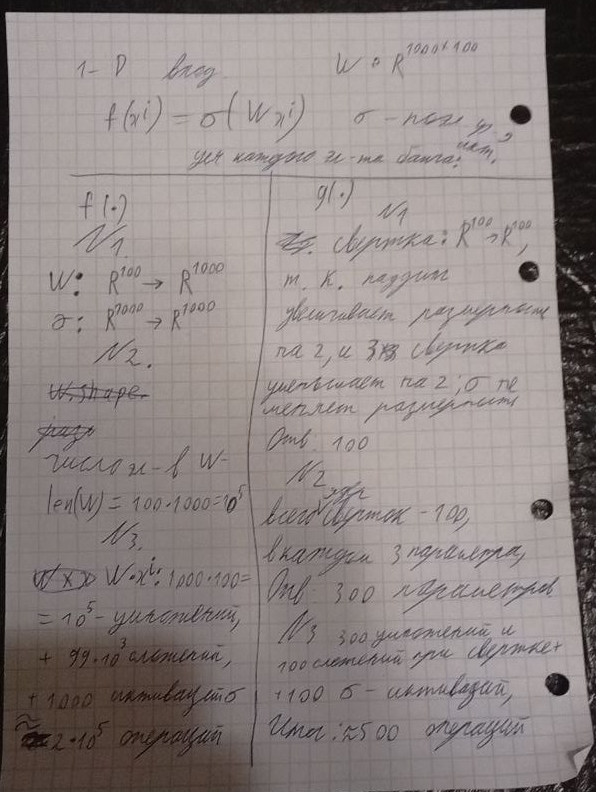

## `Бонус: постобработка изображений (1 балл)`

В предложенной задаче на фотографиях необходимо сегментировать только центральное изображения. Артефакты, которые появляются на краях изображения, можно удалять с помощью постобработки (например, с помощью модуля [skimage.morphology](https://scikit-image.org/docs/dev/api/skimage.morphology.html)).

Реализуйте какой-нибудь из методов постобработки, дающий прирост в качестве. Продемонстрируйте несколько изображений, на которых постобработка будет оказывать влияние на результат сегментации.

## `Бонус: существенное улучшение качества (2 балла)`

Придумайте какой-нибудь трюк, который существенно (с учётом бонусного пункта 1) повысит качество (которое должно быть и так достаточно высоко). Не разрешается использовать дополнительные данные или другие предобученные кодировщики кроме VGG13.

Если вы что-то попробовали, но качество не повысилось, всё равно оформите этот пункт, даже за неудачные попытки могут быть начислены баллы.

## `Бонус: обучение с использованием сторонних фреймворков (1 балл)`

Попробуйте обучить свою модель с использованием одного из следующих фреймворков: [catalyst](https://github.com/catalyst-team/catalyst), [pytorch-lightning](https://www.pytorchlightning.ai/), [ignite](https://github.com/pytorch/ignite).

## `Бонус: аугментации (0.5 балла)`

Воспользуйтесь сторонними библиотеками для аугментаций, например, [deepaugment](https://github.com/barisozmen/deepaugment) и [albumentations](https://albumentations.ai/) для улучшения качества модели.

## `Бонус: torch.compile (0.25 балла)`

Попробуйте установить [Pytorch 2.0](https://pytorch.org/get-started/pytorch-2.0/) и запустите обучение с использованием `torch.compile`. Тщательно сравните время с и без использованием компиляции.

*Замечание:* обязательно укажите конфигурацию системы (версия OS, модель CPU/GPU, объём RAM), на которой производилось обучение. В частности, приложите вывод команд:
```bash
! nvcc --version
! nvidia-smi
```